**SVD** is one of the most important mathematical tools in modern data science, machine learning, computer vision, natural language processing, and statistical genetics.

Although the name sounds intimidating, the underlying idea is elegant:

> SVD decomposes a matrix into simpler components that reveal hidden structure in the data.

SVD powers many widely used techniques, including:

- Principal Component Analysis (PCA)
- Recommendation systems
- Image compression
- Topic modeling
- Latent semantic analysis (LSA)
- Dimensionality reduction
- Noise filtering

In this tutorial, we will develop an intuitive understanding of SVD and implement it step-by-step using Python.

---

### Learning Objectives

By the end of this tutorial, you will understand:

- What SVD is
- Why matrix factorization matters
- The meaning of U, Σ, and Vᵀ
- How SVD relates to PCA
- How SVD can compress data
- Applications of SVD in machine learning
- How to implement SVD in Python

---


### Why Matrix Factorization Matters

In data science, we often work with matrices:

| Rows | Columns |
|---|---|
| Samples | Features |
| Users | Movies |
| Patients | Genes |
| Documents | Words |

These matrices are usually:

- high dimensional
- noisy
- redundant
- sparse

Matrix factorization helps us discover:

- hidden patterns
- latent structure
- lower-dimensional representations

---


### The Core Idea of SVD

SVD decomposes a matrix into three matrices:

where:

| Matrix | Meaning |
|---|---|
| U | Left singular vectors |
| Σ | Singular values |
| Vᵀ | Right singular vectors |

---

#### Intuition Behind SVD

Think of SVD as:

1. Rotating the data
2. Stretching the data
3. Rotating again

This transformation helps reveal the most important directions in the dataset.


---

### Understanding Each Component

#### 1. Matrix U

Matrix U contains the **left singular vectors**.

These vectors describe relationships among samples.

In machine learning terms:

- latent sample structure
- hidden representation of observations

---



### 2. Matrix Σ (Sigma)

Matrix $$\Sigma$$ contains the **singular values**.

These values indicate how important each latent dimension is.

Larger singular values:

- explain more variance
- capture stronger patterns

Smaller singular values often correspond to:

- noise
- redundancy

---

### 3. Matrix Vᵀ

Matrix Vᵀ contains the **right singular vectors**.

These describe relationships among features.

For example:

- gene patterns
- word associations
- correlated variables

---


#### A Simple Numerical Example

Suppose we have the following matrix:

In [1]:
import numpy as np

X = np.array([
    [1, 2],
    [3, 4],
    [5, 6]
])

X

array([[1, 2],
       [3, 4],
       [5, 6]])

In [2]:


# Computing SVD in Python

U, S, VT = np.linalg.svd(X)

print("U Matrix:")
print(U)

print("\nSingular Values:")
print(S)

print("\nV Transpose:")
print(VT)


# Understanding the Shapes

print("Shape of X:", X.shape)
print("Shape of U:", U.shape)
print("Shape of S:", S.shape)
print("Shape of VT:", VT.shape)



U Matrix:
[[-0.2298477   0.88346102  0.40824829]
 [-0.52474482  0.24078249 -0.81649658]
 [-0.81964194 -0.40189603  0.40824829]]

Singular Values:
[9.52551809 0.51430058]

V Transpose:
[[-0.61962948 -0.78489445]
 [-0.78489445  0.61962948]]
Shape of X: (3, 2)
Shape of U: (3, 3)
Shape of S: (2,)
Shape of VT: (2, 2)


### Reconstructing the Original Matrix

To reconstruct the matrix:

In [3]:


Sigma = np.zeros((3,2))
Sigma[:2, :2] = np.diag(S)

X_reconstructed = U @ Sigma @ VT

print(X_reconstructed)

[[1. 2.]
 [3. 4.]
 [5. 6.]]


---

### Interpretation

The reconstructed matrix is nearly identical to the original matrix.

This means:

- SVD preserves information efficiently
- hidden structure has been captured successfully

---


### Geometric Interpretation

SVD transforms data geometrically.

It:

- rotates data
- scales axes
- aligns major variance directions

This is why SVD is closely connected to dimensionality reduction.

---

### Relationship Between SVD and PCA

PCA is heavily based on SVD.

PCA identifies directions of maximum variance.

Mathematically:

- PCA eigenvectors come from SVD
- principal components are derived from singular vectors

---

In [4]:
# PCA Using SVD

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import pandas as pd

np.random.seed(42)

data = pd.DataFrame({
    "Feature1": np.random.normal(size=100),
    "Feature2": np.random.normal(size=100),
    "Feature3": np.random.normal(size=100)
})

scaled = StandardScaler().fit_transform(data)

pca = PCA(n_components=2)

components = pca.fit_transform(scaled)

components[:5]

array([[ 1.29174396, -1.04666426],
       [ 0.45039226, -0.11931939],
       [ 1.28477005,  0.27171728],
       [ 2.14595546, -0.08837814],
       [-0.78437651, -0.93369576]])

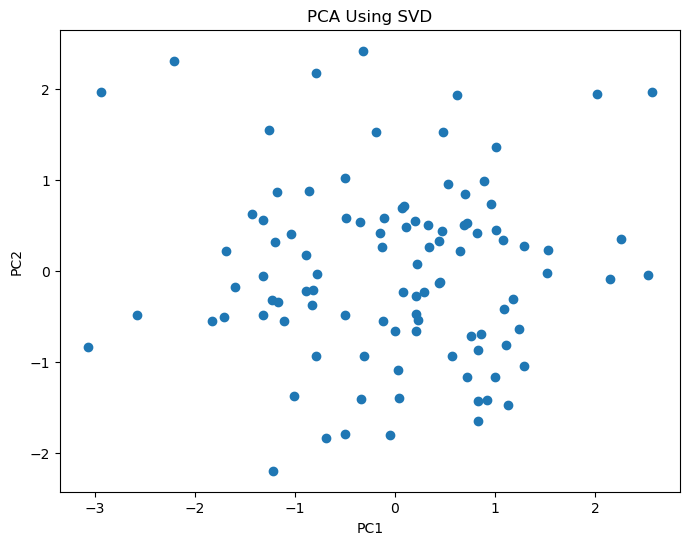

In [5]:
# Visualizing PCA Components


import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    components[:,0],
    components[:,1]
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Using SVD")
plt.show()


### Singular Values and Explained Variance

The singular values determine how much information each component contains.


In [6]:
print(pca.explained_variance_ratio_)


[0.41760625 0.32181058]



### Dimensionality Reduction

One powerful property of SVD is that we can approximate matrices using only the largest singular values.

This allows:

- compression
- denoising
- faster computation

---

### Low-Rank Approximation

Suppose we keep only the first singular value.

In [7]:

U, S, VT = np.linalg.svd(X)

k = 1

U_k = U[:, :k]
S_k = np.diag(S[:k])
VT_k = VT[:k, :]

X_approx = U_k @ S_k @ VT_k



---

### Why This Matters

This approximation:

- uses fewer parameters
- captures major structure
- removes minor noise

This idea is fundamental in:

- recommender systems
- latent semantic analysis
- image compression

---

#### Example: Image Compression

Images are matrices of pixel intensities.

SVD can compress images by storing only important singular values.

---

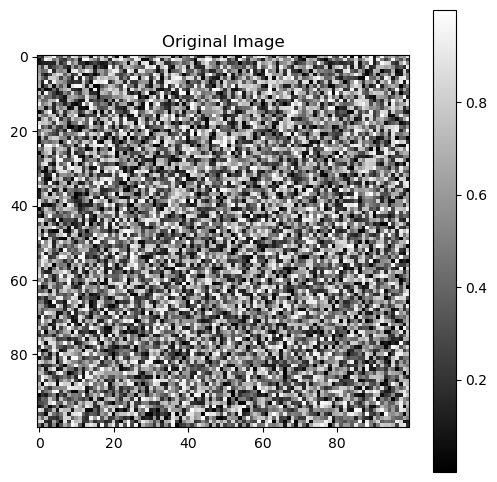

In [8]:
# Creating a Synthetic Image

image = np.random.rand(100,100)

plt.figure(figsize=(6,6))
plt.imshow(image, cmap='gray')
plt.title("Original Image")
plt.colorbar()
plt.show()

In [9]:
# Compressing the Image

U, S, VT = np.linalg.svd(image)

k = 20

#compressed = U[:, :k] @ np.diag(S[:k]) @ VT[:k, :]

compressed = np.dot(
    np.dot(U[:, :k], np.diag(S[:k])),
    VT[:k, :]
)

U, S, VT = np.linalg.svd(X)

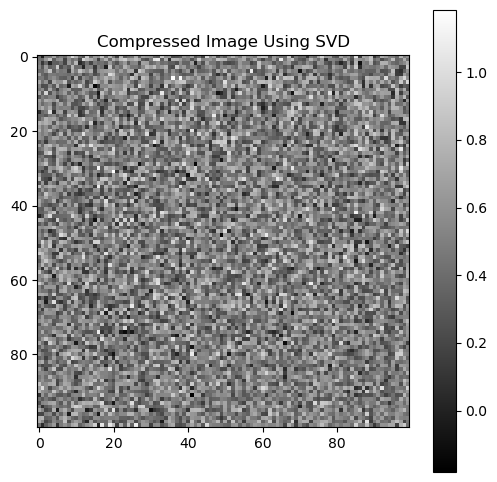

In [10]:

# Visualizing the Compressed Image

plt.figure(figsize=(6,6))
plt.imshow(compressed, cmap='gray')
plt.title("Compressed Image Using SVD")
plt.colorbar()
plt.show()

---

### Applications of SVD

| Domain | Application |
|---|---|
| NLP | Latent Semantic Analysis |
| Computer Vision | Image compression |
| Recommendation Systems | Matrix completion |
| Genetics | Population structure |
| Signal Processing | Noise reduction |
| Finance | Factor modeling |

---

#### SVD in Genomics

In genomics, SVD is widely used for:

- ancestry analysis
- batch correction
- population stratification
- gene expression decomposition
- latent factor analysis

---

#### Advantages of SVD

| Advantage | Explanation |
|---|---|
| Powerful dimensionality reduction | Captures major structure |
| Noise filtering | Removes weak components |
| Efficient representation | Compresses data |
| Broad applicability | Used across disciplines |

---

### Limitations of SVD

| Limitation | Explanation |
|---|---|
| Computationally expensive | Large matrices are costly |
| Interpretation challenges | Components may lack biological meaning |
| Sensitive to scaling | Standardization is important |

---

### Computational Complexity

SVD becomes expensive for very large datasets.

Challenges include:

- memory usage
- matrix storage
- computational time

Modern large-scale applications often rely on:

- randomized SVD
- truncated SVD
- sparse matrix methods
- GPU acceleration

---

#### Truncated SVD

 **Truncated SVD** keeps only the largest singular values.

This is particularly useful for sparse high-dimensional datasets.

---


In [11]:

# Example with Truncated SVD
from sklearn.decomposition import TruncatedSVD

svd = TruncatedSVD(n_components=2)

reduced = svd.fit_transform(scaled)

reduced[:5]



array([[ 1.29174396, -1.04666426],
       [ 0.45039226, -0.11931939],
       [ 1.28477005,  0.27171728],
       [ 2.14595546, -0.08837814],
       [-0.78437651, -0.93369576]])

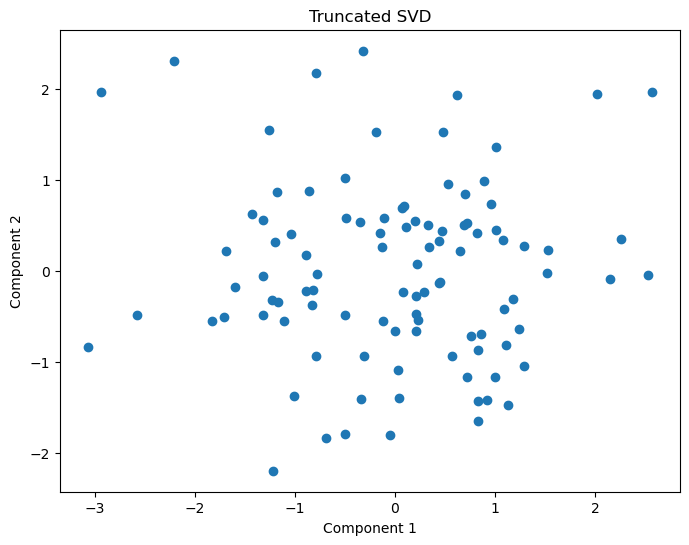

In [12]:

# Visualizing Truncated SVD
plt.figure(figsize=(8,6))

plt.scatter(
    reduced[:,0],
    reduced[:,1]
)

plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.title("Truncated SVD")
plt.show()


SVD is one of the foundational tools in data science and machine learning. It decomposes a matrix into orthogonal components that capture the hidden structure of the data. By separating important patterns from noise, SVD enables dimensionality reduction, compression, denoising, and latent representation learning.

SVD is deeply connected to Principal Component Analysis (PCA) and forms the mathematical backbone of many algorithms used in recommendation systems, natural language processing, computer vision, and genomics. Large singular values correspond to the most informative latent dimensions, while smaller singular values often represent weaker or noisy patterns.

In practice, SVD helps transform complex high-dimensional datasets into compact and interpretable representations. Despite computational challenges for extremely large matrices, modern approaches such as truncated and randomized SVD make these methods scalable for real-world machine learning applications.


---

### References

1. Hastie, Tibshirani & Friedman — The Elements of Statistical Learning
2. Bishop — Pattern Recognition and Machine Learning
3. Golub & Van Loan — Matrix Computations
4. scikit-learn documentation
5. Numerical Linear Algebra textbooks

---